In [2]:
import os
import pandas as pd

ROOT_DIR      = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset"
IMG_DIR       = f"{ROOT_DIR}/embryo_dataset/embryo_dataset"
LABEL_DIR     = f"{ROOT_DIR}/embryo_dataset_annotations/embryo_dataset_annotations"

embryo_folders   = sorted(os.listdir(IMG_DIR))
annotation_files = sorted(os.listdir(LABEL_DIR))

print(f"Embryo video folders : {len(embryo_folders)}")
print(f"Annotation CSV files : {len(annotation_files)}")
print(f"\nFirst 5 folders : {embryo_folders[:5]}")
print(f"First 5 CSVs    : {annotation_files[:5]}")


Embryo video folders : 704
Annotation CSV files : 704

First 5 folders : ['AA83-7', 'AAL839-6', 'AB028-6', 'AB91-1', 'AC264-1']
First 5 CSVs    : ['AA83-7_phases.csv', 'AAL839-6_phases.csv', 'AB028-6_phases.csv', 'AB91-1_phases.csv', 'AC264-1_phases.csv']


In [3]:
# Inspect a sample annotation file
sample_annotation = os.path.join(LABEL_DIR, annotation_files[0])
annot_sample = pd.read_csv(sample_annotation)
print(f"File: {annotation_files[0]}")
print(annot_sample)


File: AA83-7_phases.csv
   tPB2    5   24
0  tPNa   25   88
1  tPNf   89   97
2    t2   98  171
3    t3  172  177
4    t4  178  191
5    t5  192  241
6    t6  242  256
7    t7  257  276
8    t8  277  286


In [4]:
sample_vid  = embryo_folders[0]
frame_list  = sorted(os.listdir(os.path.join(IMG_DIR, sample_vid)))
print(f"Video     : {sample_vid}")
print(f"Frame cnt : {len(frame_list)}")
print(f"Examples  : {frame_list[:5]}")


Video     : AA83-7
Frame cnt : 285
Examples  : ['D2013.01.28_S0717_I132_WELL7_RUN1.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN10.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN100.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN101.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN102.jpeg']


In [5]:
for vid in embryo_folders[:3]:
    frames = sorted(os.listdir(os.path.join(IMG_DIR, vid)))
    print(f"\n{vid}: {len(frames)} frames")
    print(f"  First 3: {frames[:3]}")
    print(f"  Last  3: {frames[-3:]}")



AA83-7: 285 frames
  First 3: ['D2013.01.28_S0717_I132_WELL7_RUN1.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN10.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN100.jpeg']
  Last  3: ['D2013.01.28_S0717_I132_WELL7_RUN97.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN98.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN99.jpeg']

AAL839-6: 557 frames
  First 3: ['D2013.09.12_S0900_I132_WELL6_RUN1.jpeg', 'D2013.09.12_S0900_I132_WELL6_RUN10.jpeg', 'D2013.09.12_S0900_I132_WELL6_RUN100.jpeg']
  Last  3: ['D2013.09.12_S0900_I132_WELL6_RUN97.jpeg', 'D2013.09.12_S0900_I132_WELL6_RUN98.jpeg', 'D2013.09.12_S0900_I132_WELL6_RUN99.jpeg']

AB028-6: 291 frames
  First 3: ['D2014.01.20_S0991_I132_WELL6_RUN1.jpeg', 'D2014.01.20_S0991_I132_WELL6_RUN10.jpeg', 'D2014.01.20_S0991_I132_WELL6_RUN100.jpeg']
  Last  3: ['D2014.01.20_S0991_I132_WELL6_RUN97.jpeg', 'D2014.01.20_S0991_I132_WELL6_RUN98.jpeg', 'D2014.01.20_S0991_I132_WELL6_RUN99.jpeg']


In [7]:
vid_prefix_map = {}

for vid in embryo_folders:
    frame_files = os.listdir(os.path.join(IMG_DIR, vid))
    if frame_files:
        first_file = frame_files[0]
        prefix     = first_file.rsplit("_RUN", 1)[0]
        vid_prefix_map[vid] = prefix

print(f"Prefix map built for {len(vid_prefix_map)} videos")
print(f"Sample entries: {list(vid_prefix_map.items())[:3]}")


Prefix map built for 704 videos
Sample entries: [('AA83-7', 'D2013.01.28_S0717_I132_WELL7'), ('AAL839-6', 'D2013.09.12_S0900_I132_WELL6'), ('AB028-6', 'D2014.01.20_S0991_I132_WELL6')]


In [8]:
from tqdm import tqdm

record_list    = []
skipped_frames = 0

for annot_file in tqdm(annotation_files, desc="Indexing annotations"):
    vid_name  = annot_file.replace("_phases.csv", "")
    frame_dir = os.path.join(IMG_DIR, vid_name)

    if not os.path.exists(frame_dir):
        continue
    if vid_name not in vid_prefix_map:
        continue

    pfx    = vid_prefix_map[vid_name]
    raw_df = pd.read_csv(os.path.join(LABEL_DIR, annot_file),
                         header=None,
                         names=["stage", "f_start", "f_end"])

    for _, entry in raw_df.iterrows():
        stage_lbl = str(entry["stage"]).strip()
        idx_start = int(entry["f_start"])
        idx_end   = int(entry["f_end"])

        for fidx in range(idx_start, idx_end + 1):
            fname = f"{pfx}_RUN{fidx}.jpeg"
            fpath = os.path.join(frame_dir, fname)

            if not os.path.exists(fpath):
                skipped_frames += 1
                continue

            record_list.append({
                "video_id"   : vid_name,
                "img_path"   : fpath,
                "frame_num"  : fidx,
                "stage_label": stage_lbl
            })

full_df = pd.DataFrame(record_list)
print(f"\nTotal indexed frames : {len(full_df)}")
print(f"Frames not found     : {skipped_frames}")
print(f"\nStage distribution:\n{full_df['stage_label'].value_counts()}")
print(f"\nDistinct stages: {sorted(full_df['stage_label'].unique())}")


Indexing annotations: 100%|██████████| 704/704 [02:40<00:00,  4.39it/s]



Total indexed frames : 297428
Frames not found     : 4706

Stage distribution:
stage_label
t9+     51112
tPNa    43244
t8      32602
t2      29189
t4      29177
tEB     19535
tSB     17244
tM      17084
t7      10531
tB      10387
tPB2     8895
t6       8366
t5       8045
tPNf     6793
t3       5127
tHB        97
Name: count, dtype: int64

Distinct stages: ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']


In [9]:
from sklearn.preprocessing import LabelEncoder

stage_encoder = LabelEncoder()
full_df["class_idx"] = stage_encoder.fit_transform(full_df["stage_label"])

print("Stage to class index mapping:")
for idx, cls_name in enumerate(stage_encoder.classes_):
    cnt = (full_df["stage_label"] == cls_name).sum()
    print(f"  {idx:2d}: {cls_name:6s}  ({cnt:6d} frames)")

N_CLASSES = len(stage_encoder.classes_)
print(f"\nTotal classes: {N_CLASSES}")


Stage to class index mapping:
   0: t2      ( 29189 frames)
   1: t3      (  5127 frames)
   2: t4      ( 29177 frames)
   3: t5      (  8045 frames)
   4: t6      (  8366 frames)
   5: t7      ( 10531 frames)
   6: t8      ( 32602 frames)
   7: t9+     ( 51112 frames)
   8: tB      ( 10387 frames)
   9: tEB     ( 19535 frames)
  10: tHB     (    97 frames)
  11: tM      ( 17084 frames)
  12: tPB2    (  8895 frames)
  13: tPNa    ( 43244 frames)
  14: tPNf    (  6793 frames)
  15: tSB     ( 17244 frames)

Total classes: 16


## Train / Validation / Test Split (by video to prevent leakage)

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

all_videos = full_df["video_id"].unique()

train_vids, holdout_vids = train_test_split(all_videos, test_size=0.30, random_state=7)
val_vids,   test_vids    = train_test_split(holdout_vids, test_size=0.50, random_state=7)

train_data = full_df[full_df["video_id"].isin(train_vids)].reset_index(drop=True)
val_data   = full_df[full_df["video_id"].isin(val_vids)].reset_index(drop=True)
test_data  = full_df[full_df["video_id"].isin(test_vids)].reset_index(drop=True)

print(f"Train : {len(train_data):6d} frames  |  {len(train_vids)} videos")
print(f"Val   : {len(val_data):6d} frames  |  {len(val_vids)} videos")
print(f"Test  : {len(test_data):6d} frames  |  {len(test_vids)} videos")

assert len(set(train_vids) & set(val_vids))  == 0, "Train/Val leakage!"
assert len(set(train_vids) & set(test_vids)) == 0, "Train/Test leakage!"
assert len(set(val_vids)   & set(test_vids)) == 0, "Val/Test leakage!"
print("\nLeakage check passed!")


Train : 210600 frames  |  492 videos
Val   :  44436 frames  |  106 videos
Test  :  42392 frames  |  106 videos

Leakage check passed!


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True


class EmbryoFrameDataset(Dataset):
    """PyTorch Dataset wrapping embryo frame images."""
    def __init__(self, dataframe, aug_pipeline=None):
        self.records  = dataframe.reset_index(drop=True)
        self.pipeline = aug_pipeline

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        try:
            img = Image.open(row["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), (0, 0, 0))

        target = torch.tensor(row["class_idx"], dtype=torch.long)
        if self.pipeline:
            img = self.pipeline(img)
        return img, target


# 224x224 pipelines (MobileNet / VGG)
aug_train_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

aug_eval_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 299x299 pipelines (InceptionV3)
aug_train_299 = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

aug_eval_299 = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [12]:
compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active compute device: {compute_device}")


Active compute device: cuda


In [13]:
USE_PIN   = compute_device.type == "cuda"
N_WORKERS = 2 if compute_device.type == "cuda" else 0
BATCH_SZ  = 8

loader_train_224 = DataLoader(EmbryoFrameDataset(train_data, aug_train_224),
                               batch_size=BATCH_SZ, shuffle=True,
                               num_workers=N_WORKERS, pin_memory=USE_PIN)

loader_val_224   = DataLoader(EmbryoFrameDataset(val_data,   aug_eval_224),
                               batch_size=BATCH_SZ, shuffle=False,
                               num_workers=N_WORKERS, pin_memory=USE_PIN)

loader_test_224  = DataLoader(EmbryoFrameDataset(test_data,  aug_eval_224),
                               batch_size=BATCH_SZ, shuffle=False,
                               num_workers=N_WORKERS, pin_memory=USE_PIN)

loader_train_299 = DataLoader(EmbryoFrameDataset(train_data, aug_train_299),
                               batch_size=BATCH_SZ, shuffle=True,
                               num_workers=N_WORKERS, pin_memory=USE_PIN)

loader_val_299   = DataLoader(EmbryoFrameDataset(val_data,   aug_eval_299),
                               batch_size=BATCH_SZ, shuffle=False,
                               num_workers=N_WORKERS, pin_memory=USE_PIN)

loader_test_299  = DataLoader(EmbryoFrameDataset(test_data,  aug_eval_299),
                               batch_size=BATCH_SZ, shuffle=False,
                               num_workers=N_WORKERS, pin_memory=USE_PIN)

# Sanity check
chk_imgs, chk_lbls = next(iter(loader_train_224))
chk_imgs = chk_imgs.to(compute_device)
chk_lbls = chk_lbls.to(compute_device)
print(f"Batch shape  : {chk_imgs.shape}")
print(f"On device    : {chk_imgs.device}")
print(f"Sample labels: {chk_lbls[:8]}")
print(f"Stage names  : {[stage_encoder.classes_[i] for i in chk_lbls[:8].cpu()]}")


Batch shape  : torch.Size([8, 3, 224, 224])
On device    : cuda:0
Sample labels: tensor([ 2,  7,  2,  2, 14,  2,  3, 13], device='cuda:0')
Stage names  : ['t4', 't9+', 't4', 't4', 'tPNf', 't4', 't5', 'tPNa']


In [15]:
import torch.nn as nn
import torch.nn.functional as F

# Chronological ordering of embryo development stages
DEV_STAGES = [
    'tPB2', 'tPNa', 'tPNf',
    't2',   't3',   't4',   't5',
    't6',   't7',   't8',   't9+',
    'tM',   'tSB',  'tB',   'tEB', 'tHB'
]


def stage_position_tensor(encoder, ordered_stages, device):
    """Maps each class index to its developmental position index."""
    pos_vec = torch.zeros(len(encoder.classes_), device=device)
    for rank, stage_name in enumerate(ordered_stages):
        cidx = encoder.transform([stage_name])[0]
        pos_vec[cidx] = float(rank)
    return pos_vec


class DevStageLoss(nn.Module):
    """
    Biologically-aware combined loss:
        L_total = CrossEntropy + alpha * OrdinalDistanceLoss

    OrdinalDistanceLoss = mean_batch[ sum_k  p_k * |pos_k - pos_gt| ]
    where p_k is the softmax probability for class k.
    """
    def __init__(self, encoder, ordered_stages, alpha=0.1, device='cpu'):
        super(DevStageLoss, self).__init__()
        self.alpha  = alpha
        self.ce_fn  = nn.CrossEntropyLoss()
        self.register_buffer(
            'stage_pos',
            stage_position_tensor(encoder, ordered_stages, device)
        )

    def forward(self, logits, targets):
        loss_ce     = self.ce_fn(logits, targets)

        probs           = F.softmax(logits, dim=1)
        gt_positions    = self.stage_pos[targets]
        pred_positions  = (probs * self.stage_pos.unsqueeze(0)).sum(dim=1)
        loss_ord        = torch.abs(pred_positions - gt_positions).mean()

        total           = loss_ce + self.alpha * loss_ord
        return total, loss_ce.item(), loss_ord.item()


loss_fn = DevStageLoss(
    encoder        = stage_encoder,
    ordered_stages = DEV_STAGES,
    alpha          = 0.1,
    device         = compute_device
).to(compute_device)

print("Developmental stage ranks:")
print({s: i for i, s in enumerate(DEV_STAGES)})


Developmental stage ranks:
{'tPB2': 0, 'tPNa': 1, 'tPNf': 2, 't2': 3, 't3': 4, 't4': 5, 't5': 6, 't6': 7, 't7': 8, 't8': 9, 't9+': 10, 'tM': 11, 'tSB': 12, 'tB': 13, 'tEB': 14, 'tHB': 15}


## Model Definitions

In [18]:
from torchvision import models

def build_mobilenet_v2(n_cls):
    net = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    net.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(net.last_channel, n_cls)
    )
    return net


def build_mobilenet_v3(n_cls):
    net    = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
    in_dim = net.classifier[3].in_features
    net.classifier[3] = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_dim, n_cls)
    )
    return net


def build_vgg16(n_cls):
    net = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    net.classifier[5] = nn.Dropout(0.5)
    net.classifier[6] = nn.Linear(4096, n_cls)
    return net


def build_vgg19(n_cls):
    net = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
    net.classifier[5] = nn.Dropout(0.5)
    net.classifier[6] = nn.Linear(4096, n_cls)
    return net


def build_inception_v3(n_cls):
    net             = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
    net.AuxLogits.fc = nn.Linear(768, n_cls)
    net.fc           = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(2048, n_cls)
    )
    return net


In [19]:
def apply_backbone_freeze(net, tag):
    """Freeze feature extractor; keep only classifier head trainable."""
    if "mobilenet" in tag.lower():
        for p in net.features.parameters():    p.requires_grad = False
        for p in net.classifier.parameters():  p.requires_grad = True
    elif "vgg" in tag.lower():
        for p in net.features.parameters():    p.requires_grad = False
        for p in net.classifier.parameters():  p.requires_grad = True
    elif "inception" in tag.lower():
        for p in net.parameters():              p.requires_grad = False
        for p in net.fc.parameters():           p.requires_grad = True
        for p in net.AuxLogits.fc.parameters(): p.requires_grad = True

    n_train = sum(p.numel() for p in net.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in net.parameters())
    print(f"  [{tag}] Backbone frozen | trainable: {n_train:,} / {n_total:,} "
          f"({100*n_train/n_total:.1f}%)")
    return net


def release_all_weights(net, tag):
    """Unfreeze every parameter for full fine-tuning."""
    for p in net.parameters():
        p.requires_grad = True
    n_total = sum(p.numel() for p in net.parameters())
    print(f"  [{tag}] All weights released | {n_total:,} trainable params")
    return net


In [20]:
import time
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report


def run_train_epoch(net, loader, optim, criterion, device,
                    use_aux=False, ep=0, total_ep=10, tag=""):
    net.train()
    cum_loss = cum_ce = cum_ord = n_correct = n_total = 0
                
    bar = tqdm(loader, desc=f"[{tag}] Ep {ep+1}/{total_ep} TRAIN", leave=False)

    for imgs, lbls in bar:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optim.zero_grad()

        if use_aux:
            out, aux_out    = net(imgs)
            loss, lce, lord = criterion(out, lbls)
            aux_loss, _, _  = criterion(aux_out, lbls)
            loss = loss + 0.4 * aux_loss
        else:
            out             = net(imgs)
            loss, lce, lord = criterion(out, lbls)

        loss.backward()
        optim.step()

        cum_loss  += loss.item()
        cum_ce    += lce
        cum_ord   += lord
        preds      = out.argmax(dim=1)
        n_correct += (preds == lbls).sum().item()
        n_total   += lbls.size(0)

        bar.set_postfix(loss=f"{cum_loss/max(bar.n,1):.4f}",
                        ce  =f"{cum_ce/max(bar.n,1):.4f}",
                        ord =f"{cum_ord/max(bar.n,1):.4f}",
                        acc =f"{n_correct/n_total:.4f}")

    nb = len(loader)
    return cum_loss/nb, cum_ce/nb, cum_ord/nb, n_correct/n_total


def run_eval(net, loader, criterion, device,
             use_aux=False, phase="VAL", tag=""):
    net.eval()
    cum_loss = cum_ce = cum_ord = n_correct = n_total = 0
    pred_buf, true_buf = [], []

    bar = tqdm(loader, desc=f"[{tag}] {phase}", leave=False)

    with torch.no_grad():
        for imgs, lbls in bar:
            imgs, lbls = imgs.to(device), lbls.to(device)

            out = net(imgs)
            if isinstance(out, tuple):
                out = out[0]

            loss, lce, lord = criterion(out, lbls)
            cum_loss  += loss.item()
            cum_ce    += lce
            cum_ord   += lord
            preds      = out.argmax(dim=1)
            n_correct += (preds == lbls).sum().item()
            n_total   += lbls.size(0)
            pred_buf.extend(preds.cpu().numpy())
            true_buf.extend(lbls.cpu().numpy())

            bar.set_postfix(loss=f"{cum_loss/max(bar.n,1):.4f}",
                            acc =f"{n_correct/n_total:.4f}")

    nb = len(loader)
    return cum_loss/nb, cum_ce/nb, cum_ord/nb, n_correct/n_total, pred_buf, true_buf


def train_pipeline(tag, net, tr_loader, vl_loader,
                   use_aux=False, n_epochs=10, base_lr=1e-4):

    print(f"\n{'='*60}")
    print(f"  Pipeline : {tag}")
    print(f"{'='*60}")

    net   = net.to(compute_device)
    net   = apply_backbone_freeze(net, tag)
    optim = torch.optim.Adam(filter(lambda p: p.requires_grad, net.parameters()),
                              lr=base_lr)
    sched = torch.optim.lr_scheduler.StepLR(optim, step_size=3, gamma=0.5)

    log = {k: [] for k in ["tr_loss", "vl_loss", "tr_acc", "vl_acc",
                             "tr_ce",   "vl_ce",   "tr_ord", "vl_ord"]}

    peak_val_acc = 0.0
    ckpt_path    = f"/kaggle/working/{tag}_checkpoint.pth"

    ep_bar = tqdm(range(n_epochs), desc=f"[{tag}] Epochs", leave=True)

    for ep in ep_bar:
        t0 = time.time()

        tr_loss, tr_ce, tr_ord, tr_acc = run_train_epoch(
            net, tr_loader, optim, loss_fn, compute_device,
            use_aux, ep, n_epochs, tag)

        vl_loss, vl_ce, vl_ord, vl_acc, _, _ = run_eval(
            net, vl_loader, loss_fn, compute_device,
            use_aux, "VAL", tag)

        sched.step()

        log["tr_loss"].append(tr_loss); log["vl_loss"].append(vl_loss)
        log["tr_acc"].append(tr_acc);   log["vl_acc"].append(vl_acc)
        log["tr_ce"].append(tr_ce);     log["vl_ce"].append(vl_ce)
        log["tr_ord"].append(tr_ord);   log["vl_ord"].append(vl_ord)

        flag = ""
        if vl_acc > peak_val_acc:
            peak_val_acc = vl_acc
            torch.save(net.state_dict(), ckpt_path)
            flag = " checkpointed"

        elapsed = time.time() - t0
        ep_bar.set_postfix(tr=f"{tr_acc:.4f}", vl=f"{vl_acc:.4f}",
                           best=f"{peak_val_acc:.4f}", t=f"{elapsed:.0f}s")
        tqdm.write(
            f"  [{tag}] Ep {ep+1:02d}/{n_epochs} | "
            f"tr={tr_acc:.4f}  vl={vl_acc:.4f} | "
            f"loss={vl_loss:.4f}  ce={vl_ce:.4f}  ord={vl_ord:.4f} | "
            f"{elapsed:.1f}s{flag}"
        )

    print(f"\n  Peak val accuracy: {peak_val_acc:.4f}  ->  {ckpt_path}")
    return net, log, ckpt_path


In [16]:
torch.cuda.empty_cache()


In [17]:
NUM_EPOCHS = 4
run_logs   = {}   # model_tag -> epoch history dict

# MobileNetV2
net_mv2 = build_mobilenet_v2(N_CLASSES)
net_mv2, log_mv2, _ = train_pipeline(
    "MobileNetV2", net_mv2,
    loader_train_224, loader_val_224, n_epochs=NUM_EPOCHS)
run_logs["MobileNetV2"] = log_mv2


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s] 


  Pipeline : MobileNetV2
  [MobileNetV2] Backbone frozen | trainable: 20,496 / 2,244,368 (0.9%)


[MobileNetV2] Epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[MobileNetV2] Ep 1/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

...

[MobileNetV2] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [MobileNetV2] Ep 03/4 | tr=0.4097  vl=0.4207 | loss=1.9384  ce=1.7763  ord=1.6217 | 1171.2s checkpointed


[MobileNetV2] Ep 4/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

[MobileNetV2] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [MobileNetV2] Ep 04/4 | tr=0.4109  vl=0.4206 | loss=1.9481  ce=1.7790  ord=1.6904 | 1184.0s

  Peak val accuracy: 0.4207  ->  /kaggle/working/MobileNetV2_checkpoint.pth


In [18]:
# InceptionV3
net_inc = build_inception_v3(N_CLASSES)
net_inc, log_inc, _ = train_pipeline(
    "InceptionV3", net_inc,
    loader_train_299, loader_val_299,
    use_aux=True, n_epochs=NUM_EPOCHS)
run_logs["InceptionV3"] = log_inc

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 165MB/s] 



  Pipeline : InceptionV3
  [InceptionV3] Backbone frozen | trainable: 45,088 / 24,388,352 (0.2%)


[InceptionV3] Epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[InceptionV3] Ep 1/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

...

[InceptionV3] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [InceptionV3] Ep 03/4 | tr=0.3589  vl=0.4039 | loss=1.9775  ce=1.7964  ord=1.8110 | 1713.5s


[InceptionV3] Ep 4/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

[InceptionV3] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [InceptionV3] Ep 04/4 | tr=0.3620  vl=0.4145 | loss=1.9458  ce=1.7664  ord=1.7939 | 1662.5s

  Peak val accuracy: 0.4278  ->  /kaggle/working/InceptionV3_checkpoint.pth


In [19]:
net_vgg19 = build_vgg19(N_CLASSES)
net_vgg19, log_vgg19, _ = train_pipeline(
    "VGG19", net_vgg19,
    loader_train_224, loader_val_224, n_epochs=NUM_EPOCHS)
run_logs["VGG19"] = log_vgg19

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 197MB/s]



  Pipeline : VGG19
  [VGG19] Backbone frozen | trainable: 119,611,408 / 139,635,792 (85.7%)


[VGG19] Epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[VGG19] Ep 1/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

...

[VGG19] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [VGG19] Ep 03/4 | tr=0.5685  vl=0.4905 | loss=1.8366  ce=1.7091  ord=1.2745 | 3299.0s checkpointed


[VGG19] Ep 4/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

[VGG19] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [VGG19] Ep 04/4 | tr=0.6113  vl=0.5013 | loss=1.9679  ce=1.8435  ord=1.2437 | 3285.7s checkpointed

  Peak val accuracy: 0.5013  ->  /kaggle/working/VGG19_checkpoint.pth


In [20]:
net_vgg16 = build_vgg16(N_CLASSES)
net_vgg16, log_vgg16, _ = train_pipeline(
    "VGG16", net_vgg16,
    loader_train_224, loader_val_224, n_epochs=NUM_EPOCHS)
run_logs["VGG16"] = log_vgg16

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 226MB/s]



  Pipeline : VGG16
  [VGG16] Backbone frozen | trainable: 119,611,408 / 134,326,096 (89.0%)


[VGG16] Epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[VGG16] Ep 1/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

...

[VGG16] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [VGG16] Ep 03/4 | tr=0.5851  vl=0.5092 | loss=1.8430  ce=1.7226  ord=1.2039 | 2863.0s checkpointed


[VGG16] Ep 4/4 TRAIN:   0%|          | 0/26325 [00:00<?, ?it/s]

[VGG16] VAL:   0%|          | 0/5555 [00:00<?, ?it/s]

  [VGG16] Ep 04/4 | tr=0.6284  vl=0.5225 | loss=1.9269  ce=1.8096  ord=1.1731 | 2850.3s checkpointed

  Peak val accuracy: 0.5225  ->  /kaggle/working/VGG16_checkpoint.pth


In [21]:
print("\nAll models trained successfully!")


All models trained successfully!


## Test Set Evaluation

In [22]:
# ── Reload all models from saved checkpoints ──
from torchvision import models
import torch.nn as nn

net_mv2 = build_mobilenet_v2(N_CLASSES)
net_mv2.load_state_dict(torch.load("/kaggle/working/MobileNetV2_checkpoint.pth", map_location=compute_device))
net_mv2 = net_mv2.to(compute_device).eval()
print("MobileNetV2 loaded")

net_vgg16 = build_vgg16(N_CLASSES)
net_vgg16.load_state_dict(torch.load("/kaggle/working/VGG16_checkpoint.pth", map_location=compute_device))
net_vgg16 = net_vgg16.to(compute_device).eval()
print("VGG16 loaded")

net_vgg19 = build_vgg19(N_CLASSES)
net_vgg19.load_state_dict(torch.load("/kaggle/working/VGG19_checkpoint.pth", map_location=compute_device))
net_vgg19 = net_vgg19.to(compute_device).eval()
print("VGG19 loaded")

net_inc = build_inception_v3(N_CLASSES)
net_inc.load_state_dict(torch.load("/kaggle/working/InceptionV3_checkpoint.pth", map_location=compute_device))
net_inc = net_inc.to(compute_device).eval()
print("InceptionV3 loaded")

MobileNetV2 loaded
VGG16 loaded
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 207MB/s]  


VGG19 loaded
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 173MB/s]  


InceptionV3 loaded


In [27]:
def evaluate_on_test(tag, net, loader, use_aux=False):
    print(f"\n{'='*60}")
    print(f"Test Evaluation : {tag}")
    print(f"{'='*60}")
    loss, ce, ord_l, acc, preds, gt = run_eval(
        net, loader, loss_fn, compute_device, use_aux, "TEST", tag)
    print(f"Loss={loss:.4f}  CE={ce:.4f}  Ord={ord_l:.4f}  Acc={acc:.4f}")
    print("\nPer-class Classification Report:")
    print(classification_report(gt, preds,
                                 target_names=stage_encoder.classes_,
                                 zero_division=0))
    return acc, preds, gt


final_scores = {}

acc_mv2,   pred_mv2,   gt_mv2   = evaluate_on_test("MobileNetV2",  net_mv2,   loader_test_224)
acc_vgg16, pred_vgg16, gt_vgg16 = evaluate_on_test("VGG16",        net_vgg16, loader_test_224)
acc_vgg19, pred_vgg19, gt_vgg19 = evaluate_on_test("VGG19",        net_vgg19, loader_test_224)
acc_inc,   pred_inc,   gt_inc   = evaluate_on_test("InceptionV3",  net_inc,   loader_test_299, use_aux=True)

final_scores = {
    "MobileNetV2" : acc_mv2,
    "VGG16"       : acc_vgg16,
    "VGG19"       : acc_vgg19,
    "InceptionV3" : acc_inc,
}



Test Evaluation : MobileNetV2


[MobileNetV2] TEST:   0%|          | 0/5299 [00:00<?, ?it/s]

Loss=1.7616  CE=1.6071  Ord=1.5454  Acc=0.4505

Per-class Classification Report:
              precision    recall  f1-score   support

          t2       0.57      0.46      0.51      4615
          t3       0.00      0.00      0.00       546
          t4       0.45      0.22      0.29      4631
          t5       0.00      0.00      0.00      1070
          t6       0.00      0.00      0.00      1019
          t7       0.00      0.00      0.00      1147
          t8       0.32      0.22      0.26      5561
         t9+       0.33      0.88      0.48      6856
          tB       0.11      0.03      0.05      1099
         tEB       0.58      0.77      0.66      2636
         tHB       0.00      0.00      0.00        33
          tM       0.40      0.15      0.21      2135
        tPB2       0.38      0.14      0.20      1431
        tPNa       0.68      0.91      0.77      6370
        tPNf       0.49      0.17      0.25      1003
         tSB       0.48      0.09      0.15      2240


[VGG16] TEST:   0%|          | 0/5299 [00:00<?, ?it/s]

Loss=1.8104  CE=1.7174  Ord=0.9302  Acc=0.5652

Per-class Classification Report:
              precision    recall  f1-score   support

          t2       0.77      0.66      0.71      4615
          t3       0.05      0.01      0.02       546
          t4       0.53      0.61      0.57      4631
          t5       0.08      0.00      0.01      1070
          t6       0.03      0.01      0.02      1019
          t7       0.16      0.03      0.05      1147
          t8       0.46      0.48      0.47      5561
         t9+       0.54      0.71      0.61      6856
          tB       0.36      0.13      0.20      1099
         tEB       0.62      0.81      0.70      2636
         tHB       0.00      0.00      0.00        33
          tM       0.41      0.28      0.33      2135
        tPB2       0.38      0.59      0.46      1431
        tPNa       0.81      0.83      0.82      6370
        tPNf       0.38      0.10      0.15      1003
         tSB       0.44      0.61      0.51      2240


[VGG19] TEST:   0%|          | 0/5299 [00:00<?, ?it/s]

Loss=1.5177  CE=1.4095  Ord=1.0820  Acc=0.5400

Per-class Classification Report:
              precision    recall  f1-score   support

          t2       0.63      0.71      0.67      4615
          t3       0.00      0.00      0.00       546
          t4       0.47      0.68      0.56      4631
          t5       0.04      0.00      0.00      1070
          t6       0.00      0.00      0.00      1019
          t7       0.07      0.00      0.00      1147
          t8       0.42      0.45      0.44      5561
         t9+       0.55      0.56      0.55      6856
          tB       0.53      0.05      0.09      1099
         tEB       0.56      0.81      0.66      2636
         tHB       0.00      0.00      0.00        33
          tM       0.43      0.23      0.30      2135
        tPB2       0.41      0.08      0.14      1431
        tPNa       0.72      0.91      0.80      6370
        tPNf       0.00      0.00      0.00      1003
         tSB       0.37      0.67      0.48      2240


[InceptionV3] TEST:   0%|          | 0/5299 [00:00<?, ?it/s]

Loss=1.8303  CE=1.6638  Ord=1.6656  Acc=0.4444

Per-class Classification Report:
              precision    recall  f1-score   support

          t2       0.52      0.45      0.48      4615
          t3       0.00      0.00      0.00       546
          t4       0.39      0.26      0.31      4631
          t5       0.00      0.00      0.00      1070
          t6       0.00      0.00      0.00      1019
          t7       0.00      0.00      0.00      1147
          t8       0.38      0.18      0.24      5561
         t9+       0.35      0.86      0.50      6856
          tB       0.25      0.07      0.11      1099
         tEB       0.55      0.67      0.61      2636
         tHB       0.00      0.00      0.00        33
          tM       0.42      0.17      0.24      2135
        tPB2       0.40      0.16      0.23      1431
        tPNa       0.59      0.92      0.72      6370
        tPNf       0.54      0.03      0.05      1003
         tSB       0.35      0.18      0.24      2240


## Training Curves & Comparisons

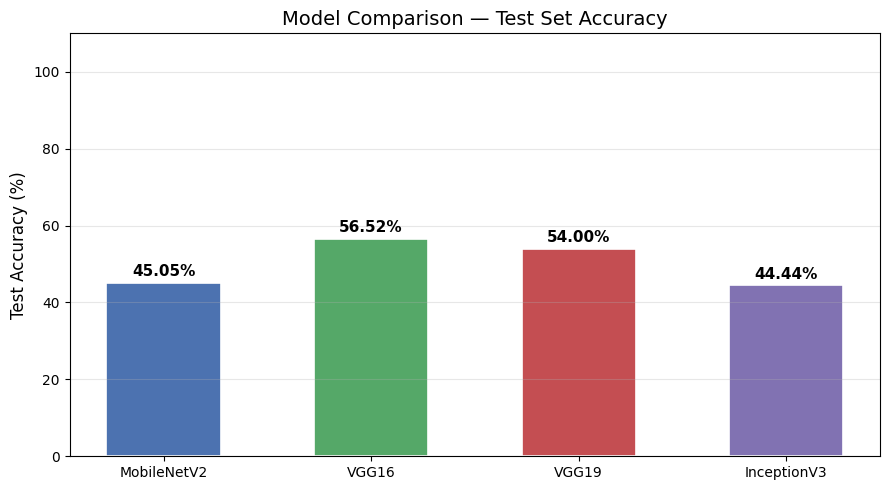

Saved: test_accuracy_bar.png


In [28]:
import matplotlib.pyplot as plt

PALETTE = {
    "MobileNetV2" : "#4C72B0",
    "VGG16"       : "#55A868",
    "VGG19"       : "#C44E52",
    "InceptionV3" : "#8172B2",
}

# Figure 5: Test accuracy bar chart only
model_names = list(final_scores.keys())
test_accs   = [final_scores[m] * 100 for m in model_names]
bar_colors  = [PALETTE[m] for m in model_names]

fig5, ax5 = plt.subplots(figsize=(9, 5))
rects = ax5.bar(model_names, test_accs, color=bar_colors,
                edgecolor="white", linewidth=1.2, width=0.55)
ax5.set_ylabel("Test Accuracy (%)", fontsize=12)
ax5.set_title("Model Comparison — Test Set Accuracy", fontsize=14)
ax5.set_ylim(0, 110)
ax5.grid(axis="y", alpha=0.3)

for rect, val in zip(rects, test_accs):
    ax5.text(rect.get_x() + rect.get_width() / 2,
             rect.get_height() + 1,
             f"{val:.2f}%",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/test_accuracy_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: test_accuracy_bar.png")

## Summary Table

In [29]:
rows = []
for tag, acc in final_scores.items():
    rows.append({"Model": tag, "Test Acc": f"{acc * 100:.2f}%"})

summary_tbl = pd.DataFrame(rows)
print(summary_tbl.to_string(index=False))
summary_tbl.to_csv("/kaggle/working/model_summary.csv", index=False)
print("\nSummary saved to model_summary.csv")

      Model Test Acc
MobileNetV2   45.05%
      VGG16   56.52%
      VGG19   54.00%
InceptionV3   44.44%

Summary saved to model_summary.csv
